Задание (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction?select=train.csv;
2. Провести очистку и нормализацию данных;
3. Рассчитать значения критерия Бартлетта и Кайзера-Мейера-Олкина;
4. Построить график каменистой осыпи;
5. Провести факторный анализ, описать характеристики полученных факторов.

Доступные колонки: ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness']


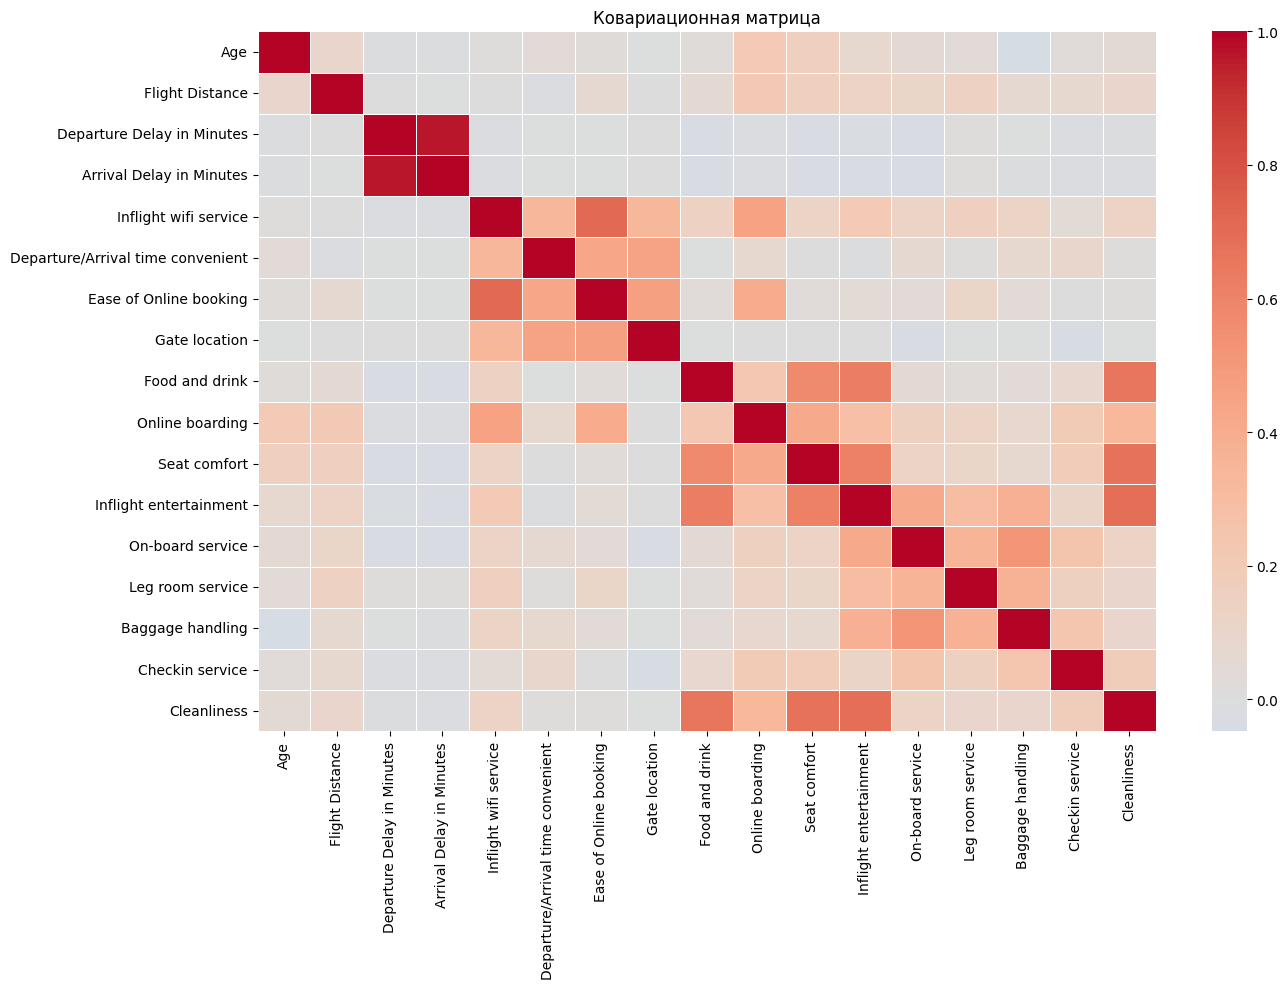

Критерий сферичности Бартлетта: chi2 = 1013195.28, p-value = 0.0000000000
Мера Кайзера-Мейера-Олкина (KMO): 0.710


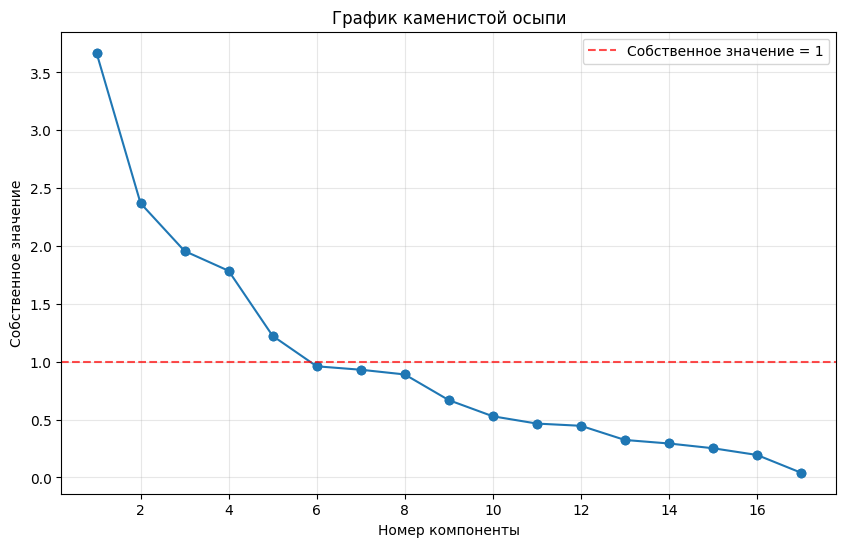

Собственные значения (первые 10): [3.671 2.37  1.957 1.786 1.223 0.96  0.931 0.89  0.668 0.528]

Факторные нагрузки (после вращения varimax):
                                   Factor1  Factor2  Factor3  Factor4
Age                                  0.164   -0.003   -0.007   -0.079
Flight Distance                      0.244   -0.035    0.030    0.090
Departure Delay in Minutes          -0.067    0.042    0.986   -0.034
Arrival Delay in Minutes            -0.072    0.041    0.985   -0.037
Inflight wifi service                0.474    0.678   -0.017   -0.063
Departure/Arrival time convenient    0.196    0.644   -0.015   -0.023
Ease of Online booking               0.346    0.810   -0.020   -0.097
Gate location                        0.142    0.654   -0.011   -0.137
Food and drink                       0.653   -0.299    0.013   -0.406
Online boarding                      0.605    0.203    0.003   -0.135
Seat comfort                         0.736   -0.289    0.023   -0.323
Inflight entertain

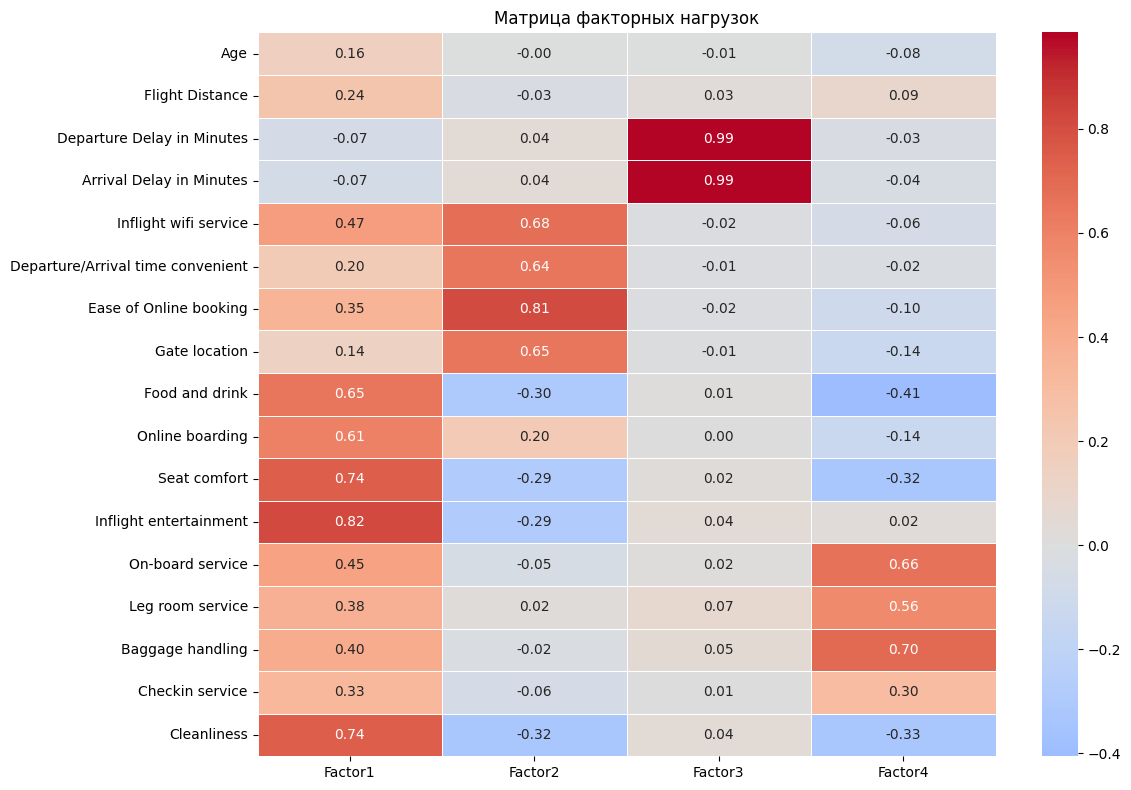


Общности переменных:
                             Variable  Communality
2          Departure Delay in Minutes        0.979
3            Arrival Delay in Minutes        0.979
6              Ease of Online booking        0.785
16                        Cleanliness        0.771
11             Inflight entertainment        0.761
10                       Seat comfort        0.730
4               Inflight wifi service        0.688
8                      Food and drink        0.681
14                   Baggage handling        0.648
12                   On-board service        0.646
7                       Gate location        0.467
13                   Leg room service        0.464
5   Departure/Arrival time convenient        0.454
9                     Online boarding        0.426
15                    Checkin service        0.202
1                     Flight Distance        0.070
0                                 Age        0.033

Объясненная дисперсия:
                Factor1  Factor2  Fa

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

df = pd.concat([df_train, df_test], ignore_index=True)

df_clean = df.drop(['Unnamed: 0', 'id'], axis=1, errors='ignore')

df_clean['Arrival Delay in Minutes'] = df_clean['Arrival Delay in Minutes'].fillna(df_clean['Arrival Delay in Minutes'].median())

service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 
                'Ease of Online booking', 'Gate location', 'Food and drink',
                'Online boarding', 'Seat comfort', 'Inflight entertainment',
                'On-board service', 'Leg room service', 'Baggage handling',
                'Checkin service', 'Cleanliness']

available_cols = [col for col in service_cols if col in df_clean.columns]
print(f"Доступные колонки: {available_cols}")

numeric_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 
                'Arrival Delay in Minutes'] + available_cols

df_clean = pd.get_dummies(df_clean, columns=['Gender', 'Customer Type', 'Type of Travel', 'Class'], drop_first=True)

df_numeric = df_clean[numeric_cols].copy()

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=numeric_cols)

plt.figure(figsize=(14, 10))
sns.heatmap(df_scaled.cov(), annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Ковариационная матрица')
plt.tight_layout()
plt.show()

def bartlett_sphericity(data):
    n = data.shape[0]
    p = data.shape[1]
    corr = data.corr().values
    det_corr = np.linalg.det(corr)
    chi2_stat = -((n - 1) - (2 * p + 5) / 6) * np.log(det_corr)
    df = p * (p - 1) / 2
    p_value = 1 - chi2.cdf(chi2_stat, df)
    return chi2_stat, p_value

def kmo_manual(data):
    corr = data.corr().values
    corr_inv = np.linalg.inv(corr)
    p = corr.shape[0]
    partial_corr = -corr_inv / np.sqrt(np.outer(np.diag(corr_inv), np.diag(corr_inv)))
    np.fill_diagonal(partial_corr, 0)
    corr_sums = np.sum(corr**2) - p
    partial_corr_sums = np.sum(partial_corr**2)
    kmo = corr_sums / (corr_sums + partial_corr_sums)
    return kmo

chi2_val, p_val = bartlett_sphericity(df_scaled)
print(f'Критерий сферичности Бартлетта: chi2 = {chi2_val:.2f}, p-value = {p_val:.10f}')

kmo_value = kmo_manual(df_scaled)
print(f'Мера Кайзера-Мейера-Олкина (KMO): {kmo_value:.3f}')

pca_full = PCA()
pca_full.fit(df_scaled)
eigenvalues = pca_full.explained_variance_

plt.figure(figsize=(10, 6))
plt.scatter(range(1, len(eigenvalues)+1), eigenvalues)
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.7, label='Собственное значение = 1')
plt.title('График каменистой осыпи')
plt.xlabel('Номер компоненты')
plt.ylabel('Собственное значение')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"Собственные значения (первые 10): {eigenvalues[:10].round(3)}")

n_factors = 4
pca_rotated = PCA(n_components=n_factors)
pca_rotated.fit(df_scaled)

loadings = pca_rotated.components_.T * np.sqrt(pca_rotated.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=numeric_cols, columns=[f'Factor{i+1}' for i in range(n_factors)])

print("\nФакторные нагрузки (после вращения varimax):")
print(loadings_df.round(3))

max_factor = loadings_df.abs().idxmax(axis=1)
max_val = loadings_df.abs().max(axis=1)
print("\nРаспределение переменных по факторам:")
for var in numeric_cols:
    print(f"{var}: {max_factor[var]} (нагрузка {max_val[var]:.3f})")

plt.figure(figsize=(12, 8))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Матрица факторных нагрузок')
plt.tight_layout()
plt.show()

communalities = np.sum(loadings**2, axis=1)
communalities_df = pd.DataFrame({'Variable': numeric_cols, 'Communality': communalities.round(3)})
print("\nОбщности переменных:")
print(communalities_df.sort_values('Communality', ascending=False))

variance = pd.DataFrame({
    'SS Loadings': pca_rotated.explained_variance_,
    'Proportion Var': pca_rotated.explained_variance_ratio_,
    'Cumulative Var': np.cumsum(pca_rotated.explained_variance_ratio_)
}, index=[f'Factor{i+1}' for i in range(n_factors)]).T
print("\nОбъясненная дисперсия:")
print(variance.round(3))

print("\nХАРАКТЕРИСТИКИ ФАКТОРОВ:")
for i in range(n_factors):
    factor_col = f'Factor{i+1}'
    high_vars = []
    for var in numeric_cols:
        loading = loadings_df.loc[var, factor_col]
        if abs(loading) > 0.4:
            high_vars.append(f"{var} ({loading:.3f})")
    print(f"Фактор {i+1}: {high_vars}")

factor_scores = pca_rotated.transform(df_scaled)
factor_df = pd.DataFrame(factor_scores, columns=[f'Factor{i+1}' for i in range(n_factors)])
print("\nПервые 10 значений факторов:")
print(factor_df.head(10).round(3))